In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
df = pd .read_csv('/content/SuperStoreOrders.csv')
df.head(5)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [37]:
df.shape

(51290, 21)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [39]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [40]:
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [49]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed')
df['Month'] = df['order_date'].dt.to_period('M')
df['Year'] = df['order_date'].dt.year

In [42]:
df['sales'] = df['sales'].str.replace(',', '')
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [44]:
df['sales'].isnull().sum()

np.int64(0)

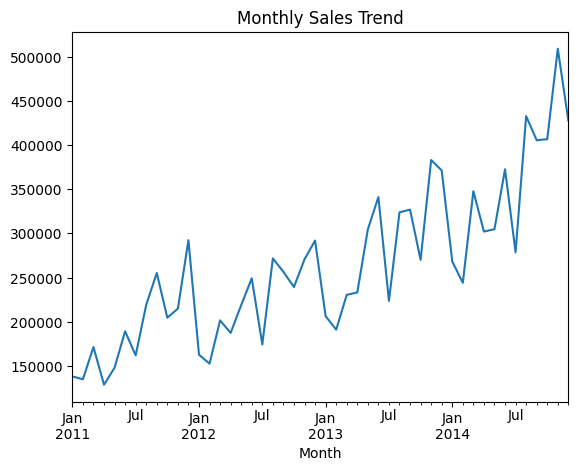

In [50]:
# Monthly sales trend
df.groupby(df['Month'])['sales'].sum().plot()
plt.title("Monthly Sales Trend")
plt.show()

In [48]:
print("Total Sales:", df['sales'].sum())
print("Total Profit:", df['profit'].sum())

Total Sales: 12642905
Total Profit: 1469034.8212799998


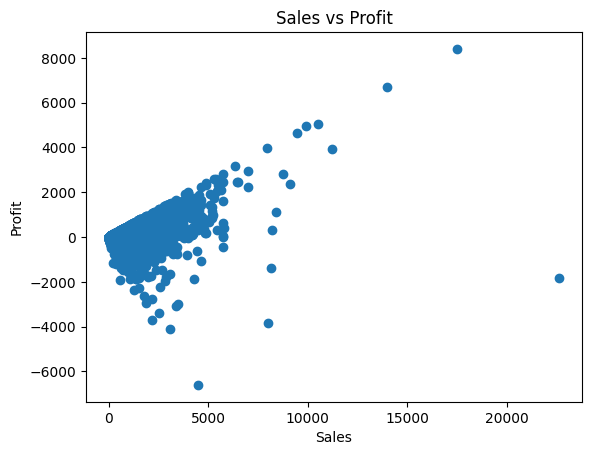

In [52]:
#Profit vs Sales
plt.scatter(df['sales'], df['profit'])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

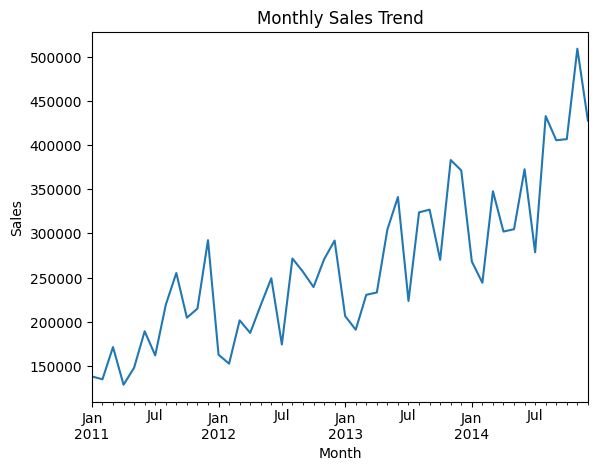

In [51]:
#Monthly Sales Trend
monthly_sales = df.groupby('Month')['sales'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

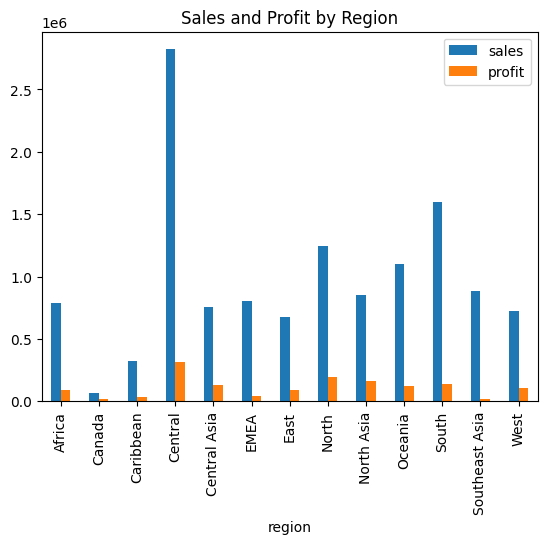

In [53]:
#Region wise Performance
df.groupby('region')[['sales','profit']].sum().plot(kind='bar')
plt.title("Sales and Profit by Region")
plt.show()

In [54]:
#identify loss drivers
df[df['profit'] < 0].sort_values('profit').head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,Month,Year
31884,CA-2013-108196,2013-11-26,3/12/2013,Standard Class,Cindy Stewart,Consumer,Ohio,United States,US,East,...,Cubify CubeX 3D Printer Double Head Print,4500,5,0.7,-6599.9780,451.63,Low,2013,2013-11,2013
29212,TU-2013-9400,2013-09-26,26-09-2013,Same Day,Denise Monton,Corporate,Izmir,Turkey,EMEA,EMEA,...,"Motorola Smart Phone, Cordless",3085,12,0.6,-4088.3760,51.89,Critical,2013,2013-09,2013
47195,US-2014-168116,2014-05-11,5/11/2014,Same Day,Grant Thornton,Corporate,North Carolina,United States,US,South,...,Cubify CubeX 3D Printer Triple Head Print,8000,4,0.5,-3839.9904,674.82,High,2014,2014-05,2014
3775,CA-2011-169019,2011-07-26,30-07-2011,Standard Class,Luke Foster,Consumer,Texas,United States,US,Central,...,GBC DocuBind P400 Electric Binding System,2178,8,0.8,-3701.8928,172.07,Medium,2011,2011-07,2011
37130,CA-2014-134845,2014-04-18,24-04-2014,Standard Class,Sharelle Roach,Home Office,Colorado,United States,US,West,...,Lexmark MX611dhe Monochrome Laser Printer,2550,5,0.7,-3399.9800,120.31,Medium,2014,2014-04,2014


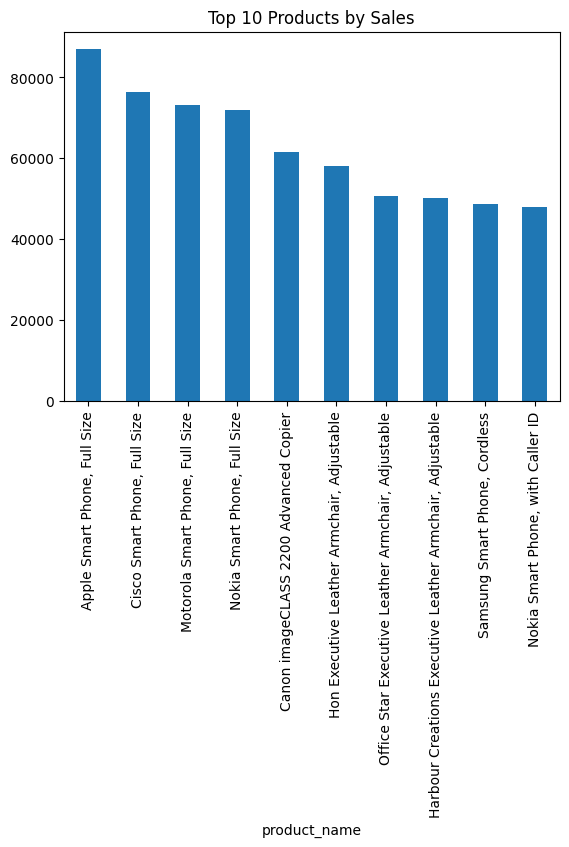

In [56]:
#Top products
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.show()